# **LEBOGANG VELDSMAN-ANALYSIS**

[https://www.kaggle.com/datasets/vivek468/superstore-dataset-final](http://)

In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input",recursive=TRUE,full.names=TRUE)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "../input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv"

In [8]:
data <- list.files(path = "../input/datasets/vivek468/superstore-dataset-final/",recursive=TRUE,full.names=TRUE)

In [9]:
head(data)

[1] "../input/datasets/vivek468/superstore-dataset-final//Sample - Superstore.csv"

In [11]:
superStore <- read.csv(data[1])

In [12]:
head(superStore)

,Row.ID,Order.ID,Order.Date,Ship.Date,Ship.Mode,Customer.ID,Customer.Name,Segment,Country,City,⋯,Postal.Code,Region,Product.ID,Category,Sub.Category,Product.Name,Sales,Quantity,Discount,Profit
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>
1,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,⋯,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
2,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,⋯,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400,3,0.00,219.5820
3,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,⋯,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.6200,2,0.00,6.8714
4,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,⋯,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
5,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,⋯,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
6,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,⋯,90032,West,FUR-FU-10001487,Furniture,Furnishings,"Eldon Expressions Wood and Plastic Desk Accessories, Cherry Wood",48.8600,7,0.00,14.1694


# Your goal is not just to create charts, but to help a business answer important questions such as:


## Which products generate the most revenue?
## How do sales change over time?
## Which categories or regions are most profitable?
## Where should the business focus to grow faster?


In [13]:
# Check total number of missing values in the dataset
sum(is.na(superStore))

# Check missing values per column
colSums(is.na(superStore))

# Check missing values per row
rowSums(is.na(superStore))

[1] 0

Row.ID      Order.ID    Order.Date     Ship.Date     Ship.Mode 
            0             0             0             0             0 
  Customer.ID Customer.Name       Segment       Country          City 
            0             0             0             0             0 
        State   Postal.Code        Region    Product.ID      Category 
            0             0             0             0             0 
 Sub.Category  Product.Name         Sales      Quantity      Discount 
            0             0             0             0             0 
       Profit 
            0

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [38] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  [75] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [112] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [149] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [186] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [223] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [260] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [297] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [334] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [371] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [408] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [445] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [482] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [519] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [556] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [593] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [630] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [667] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [704] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [741] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [778] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [815] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [852] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [889] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [926] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [963] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1000] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1037] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1074] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1111] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1148] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1185] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1222] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1259] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1296] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1333] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1370] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1407] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1444] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1481] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1518] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1555] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1592] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1629] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1666] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1703] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1740] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1777] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
[1814] 0 0 0 0 0 0 0 0 0 0 0 0 0 0

**There are no missing values**

In [17]:
# Check the total number of duplicate rows (excluding the first occurrence)
sum(duplicated(superStore))

# View the actual duplicate rows
superStore[duplicated(superStore), ]

# View ALL rows involved in duplication (including the first occurrence)
superStore[duplicated(superStore) | duplicated(superStore, fromLast = TRUE), ]

# Check for duplicates based on specific column(s), e.g. an ID column
sum(duplicated(superStore$OrderID))
superStore[duplicated(superStore$OrderID) | duplicated(superStore$OrderID, fromLast = TRUE), ]

[1] 0

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


Row.ID,Order.ID,Order.Date,Ship.Date,Ship.Mode,Customer.ID,Customer.Name,Segment,Country,City,⋯,Postal.Code,Region,Product.ID,Category,Sub.Category,Product.Name,Sales,Quantity,Discount,Profit
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>


Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


Row.ID,Order.ID,Order.Date,Ship.Date,Ship.Mode,Customer.ID,Customer.Name,Segment,Country,City,⋯,Postal.Code,Region,Product.ID,Category,Sub.Category,Product.Name,Sales,Quantity,Discount,Profit
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>


[1] 0

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


Row.ID,Order.ID,Order.Date,Ship.Date,Ship.Mode,Customer.ID,Customer.Name,Segment,Country,City,⋯,Postal.Code,Region,Product.ID,Category,Sub.Category,Product.Name,Sales,Quantity,Discount,Profit
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>


'data.frame':	9994 obs. of  21 variables:
 $ Row.ID       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Order.ID     : chr  "CA-2016-152156" "CA-2016-152156" "CA-2016-138688" "US-2015-108966" ...
 $ Order.Date   : chr  "11/8/2016" "11/8/2016" "6/12/2016" "10/11/2015" ...
 $ Ship.Date    : chr  "11/11/2016" "11/11/2016" "6/16/2016" "10/18/2015" ...
 $ Ship.Mode    : chr  "Second Class" "Second Class" "Second Class" "Standard Class" ...
 $ Customer.ID  : chr  "CG-12520" "CG-12520" "DV-13045" "SO-20335" ...
 $ Customer.Name: chr  "Claire Gute" "Claire Gute" "Darrin Van Huff" "Sean O'Donnell" ...
 $ Segment      : chr  "Consumer" "Consumer" "Corporate" "Consumer" ...
 $ Country      : chr  "United States" "United States" "United States" "United States" ...
 $ City         : chr  "Henderson" "Henderson" "Los Angeles" "Fort Lauderdale" ...
 $ State        : chr  "Kentucky" "Kentucky" "California" "Florida" ...
 $ Postal.Code  : int  42420 42420 90036 33311 33311 90032 90032 90032 90032 90032 ...
 $ Reg

[1] 9994   21

[1] "Row.ID"        "Order.ID"      "Order.Date"    "Ship.Date"    
 [5] "Ship.Mode"     "Customer.ID"   "Customer.Name" "Segment"      
 [9] "Country"       "City"          "State"         "Postal.Code"  
[13] "Region"        "Product.ID"    "Category"      "Sub.Category" 
[17] "Product.Name"  "Sales"         "Quantity"      "Discount"     
[21] "Profit"

Row.ID      Order.ID    Order.Date     Ship.Date     Ship.Mode 
    "integer"   "character"   "character"   "character"   "character" 
  Customer.ID Customer.Name       Segment       Country          City 
  "character"   "character"   "character"   "character"   "character" 
        State   Postal.Code        Region    Product.ID      Category 
  "character"     "integer"   "character"   "character"   "character" 
 Sub.Category  Product.Name         Sales      Quantity      Discount 
  "character"   "character"     "numeric"     "integer"     "numeric" 
       Profit 
    "numeric"

     Row.ID       Order.ID          Order.Date         Ship.Date        
 Min.   :   1   Length:9994        Length:9994        Length:9994       
 1st Qu.:2499   Class :character   Class :character   Class :character  
 Median :4998   Mode  :character   Mode  :character   Mode  :character  
 Mean   :4998                                                           
 3rd Qu.:7496                                                           
 Max.   :9994                                                           
  Ship.Mode         Customer.ID        Customer.Name        Segment         
 Length:9994        Length:9994        Length:9994        Length:9994       
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                           

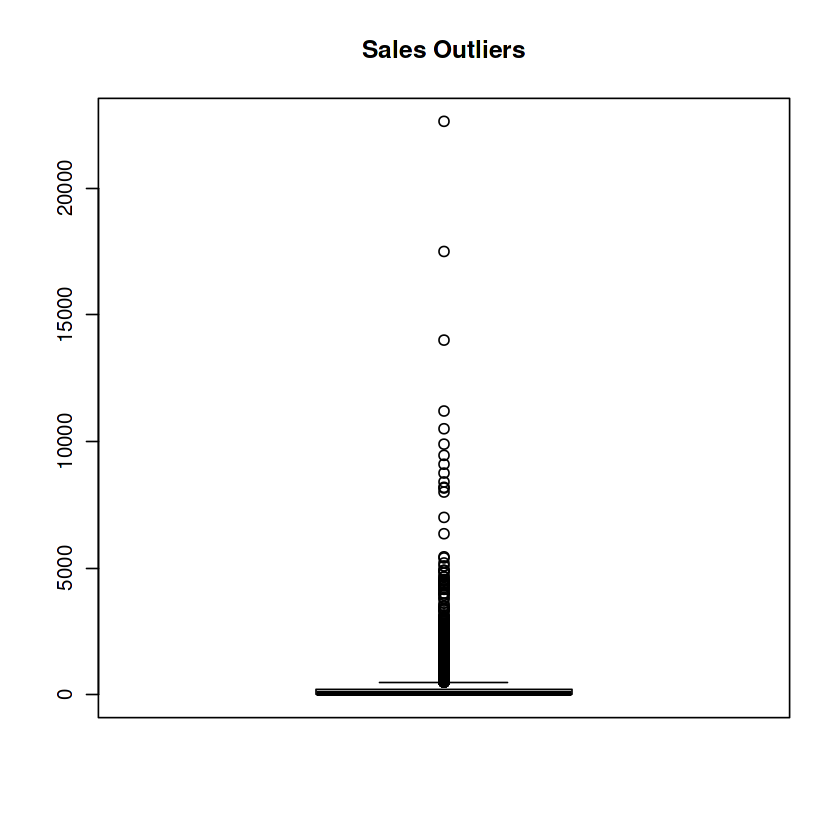

$Order.ID
   [1] "CA-2016-152156" "CA-2016-138688" "US-2015-108966" "CA-2014-115812"
   [5] "CA-2017-114412" "CA-2016-161389" "US-2015-118983" "CA-2014-105893"
   [9] "CA-2014-167164" "CA-2014-143336" "CA-2016-137330" "US-2017-156909"
  [13] "CA-2015-106320" "CA-2016-121755" "US-2015-150630" "CA-2017-107727"
  [17] "CA-2016-117590" "CA-2015-117415" "CA-2017-120999" "CA-2016-101343"
  [21] "CA-2017-139619" "CA-2016-118255" "CA-2014-146703" "CA-2016-169194"
  [25] "CA-2015-115742" "CA-2016-105816" "CA-2016-111682" "CA-2015-135545"
  [29] "US-2015-164175" "CA-2014-106376" "CA-2016-119823" "CA-2016-106075"
  [33] "CA-2017-114440" "US-2015-134026" "US-2017-118038" "US-2014-147606"
  [37] "CA-2016-127208" "CA-2014-139451" "CA-2015-149734" "US-2017-119662"
  [41] "CA-2017-140088" "CA-2017-155558" "CA-2016-159695" "CA-2016-109806"
  [45] "CA-2015-149587" "US-2017-109484" "CA-2017-161018" "CA-2017-157833"
  [49] "CA-2016-149223" "CA-2016-158568" "CA-2016-129903" "US-2015-156867"
  [53] "CA-2017-119004" "CA-2015-129476" "CA-2017-146780" "CA-2016-128867"
  [57] "CA-2014-115259" "CA-2015-110457" "US-2015-136476" "CA-2016-103730"
  [61] "US-2014-152030" "US-2014-134614" "US-2017-107272" "US-2016-125969"
  [65] "US-2017-164147" "CA-2016-145583" "CA-2016-110366" "CA-2017-106180"
  [69] "CA-2017-155376" "CA-2015-110744" "CA-2014-110072" "CA-2016-114489"
  [73] "CA-2016-158834" "CA-2015-124919" "CA-2015-118948" "CA-2014-104269"
  [77] "CA-2016-114104" "CA-2016-162733" "CA-2015-119697" "CA-2016-154508"
  [81] "CA-2016-113817" "CA-2014-139892" "CA-2014-118962" "US-2014-100853"
  [85] "US-2017-152366" "US-2015-101511" "CA-2015-137225" "CA-2014-166191"
  [89] "CA-2014-158274" "CA-2016-105018" "CA-2014-123260" "CA-2016-157000"
  [93] "CA-2015-102281" "CA-2015-131457" "CA-2014-140004" "CA-2017-107720"
  [97] "US-2017-124303" "CA-2017-105074" "CA-2014-133690" "US-2017-116701"
 [101] "CA-2017-126382" "CA-2017-108329" "CA-2017-135860" "CA-2015-101007"
 [105] "CA-2015-146262" "CA-2016-130162" "CA-2015-169397" "CA-2015-163055"
 [109] "US-2015-145436" "US-2014-156216" "US-2017-100930" "CA-2017-160514"
 [113] "CA-2016-157749" "CA-2014-131926" "CA-2016-154739" "CA-2016-145625"
 [117] "CA-2016-146941" "US-2015-159982" "CA-2017-163139" "US-2017-155299"
 [121] "US-2014-106992" "CA-2016-125318" "CA-2015-155040" "CA-2017-136826"
 [125] "CA-2016-111010" "US-2017-145366" "CA-2017-163979" "CA-2015-155334"
 [129] "CA-2017-118136" "CA-2017-132976" "US-2015-161991" "CA-2015-130890"
 [133] "CA-2015-130883" "CA-2016-112697" "CA-2016-110772" "CA-2014-111451"
 [137] "CA-2016-142545" "US-2017-152380" "CA-2015-144253" "CA-2014-130960"
 [141] "CA-2014-111003" "CA-2017-126774" "CA-2016-142902" "CA-2014-120887"
 [145] "CA-2014-167850" "CA-2014-164259" "CA-2014-164973" "CA-2014-156601"
 [149] "CA-2016-162138" "CA-2017-153339" "US-2016-141544" "US-2016-150147"
 [153] "CA-2015-137946" "CA-2014-129924" "CA-2015-128167" "CA-2014-122336"
 [157] "US-2015-120712" "CA-2017-169901" "CA-2017-134306" "CA-2016-129714"
 [161] "CA-2016-138520" "CA-2016-130001" "CA-2017-155698" "CA-2017-144904"
 [165] "CA-2014-123344" "CA-2016-155516" "CA-2017-104745" "US-2014-119137"
 [169] "US-2016-134656" "US-2017-134481" "CA-2015-130792" "CA-2016-134775"
 [173] "CA-2015-125395" "US-2015-168935" "CA-2015-122756" "CA-2014-115973"
 [177] "CA-2017-101798" "US-2014-135972" "US-2014-134971" "CA-2017-102946"
 [181] "CA-2017-165603" "CA-2015-122259" "CA-2016-108987" "CA-2014-113166"
 [185] "CA-2014-155208" "CA-2017-117933" "CA-2017-117457" "CA-2017-142636"
 [189] "CA-2017-122105" "CA-2016-148796" "CA-2017-154816" "CA-2017-110478"
 [193] "CA-2014-142048" "CA-2017-125388" "CA-2017-155705" "CA-2017-149160"
 [197] "CA-2014-101476" "CA-2017-152275" "US-2016-123750" "CA-2016-127369"
 [201] "US-2014-150574" "CA-2016-147375" "CA-2017-130043" "CA-2017-157252"
 [205] "CA-2016-115756" "CA-2017-154214" "CA-2016-166674" "CA-2017-147277"
 [209] "CA-2016-100153" "US-2014-110674" "US-2016-157945" "CA-2015-109638"
 [213] "CA-2016

ERROR: Error in sub(re, "", x, perl = TRUE): input string 405 is invalid UTF-8


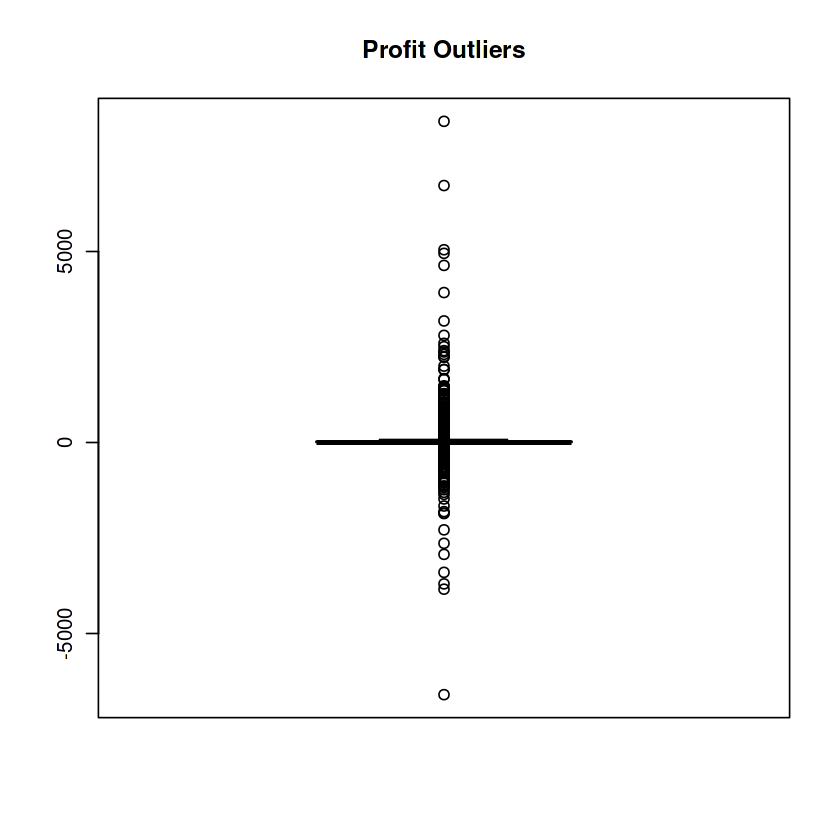

In [19]:
# 1. Get a structural overview
str(superStore)
dim(superStore)
names(superStore)

# 2. Check data types are correct (e.g. dates read as dates, not strings)
sapply(superStore, class)

# 3. Summary statistics for numeric columns
summary(superStore)

# 4. Check for outliers in key numeric columns (e.g. Sales, Profit, Quantity)
boxplot(superStore$Sales, main = "Sales Outliers")
boxplot(superStore$Profit, main = "Profit Outliers")

# 5. Check categorical columns for inconsistent labels (e.g. "california" vs "California")
sapply(superStore[sapply(superStore, is.character)], unique)

# 6. Check for blank strings or whitespace-only values (NA won't catch these)
sapply(superStore, function(x) sum(trimws(x) == "", na.rm = TRUE))

# 7. Check date ranges make sense
range(superStore$OrderDate)

## **1. Which products generate the most revenue?**

In [21]:
# --- 0. Clean up first (dates, encoding) ---
superStore$Order.Date <- as.Date(superStore$Order.Date, format = "%m/%d/%Y")
superStore$Ship.Date  <- as.Date(superStore$Ship.Date, format = "%m/%d/%Y")

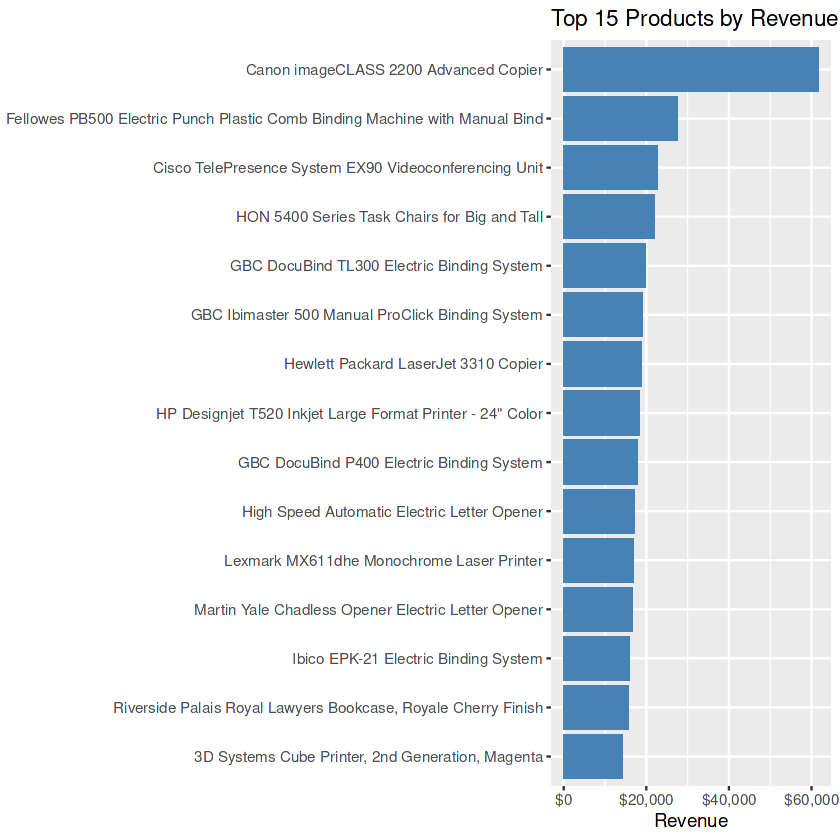

In [23]:
top_products <- superStore %>%
  group_by(Product.Name) %>%
  summarise(Revenue = sum(Sales), Profit = sum(Profit), Orders = n_distinct(Order.ID)) %>%
  arrange(desc(Revenue)) %>%
  head(15)

ggplot(top_products, aes(x = reorder(Product.Name, Revenue), y = Revenue)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 15 Products by Revenue", x = NULL, y = "Revenue") +
 scale_y_continuous(labels = scales::dollar)

**1. Top Products by Revenue**

Your top performer, the Canon imageCLASS 2200 Advanced Copier, generates roughly 3x the revenue of the next closest product — a huge outlier rather than part of a smooth curve. That's worth flagging on its own: a single SKU that dominant is both an opportunity (it's clearly a hero product) and a risk (you're concentrated in one item — any supply, pricing, or competitive disruption to that copier hits revenue hard).

Notice the list is dominated by big-ticket equipment — copiers, binding systems, printers, a bookcase — not everyday office supplies. This tells you revenue is being driven by a small number of expensive, infrequent purchases rather than volume sales. That has a direct implication for question 4 (where to focus): growth here likely comes from account-based selling to businesses (equipment refreshes, bulk office setups) rather than consumer-style marketing.

 One caveat: this chart shows revenue only, not profit. I'd pull profit/margin for these same 15 products next — high-ticket equipment like copiers and printers often carries thin margins, so your "top revenue" list and "top profit" list may look quite different.



##  **2. How do sales change over time?**

`geom_smooth()` using formula = 'y ~ x'


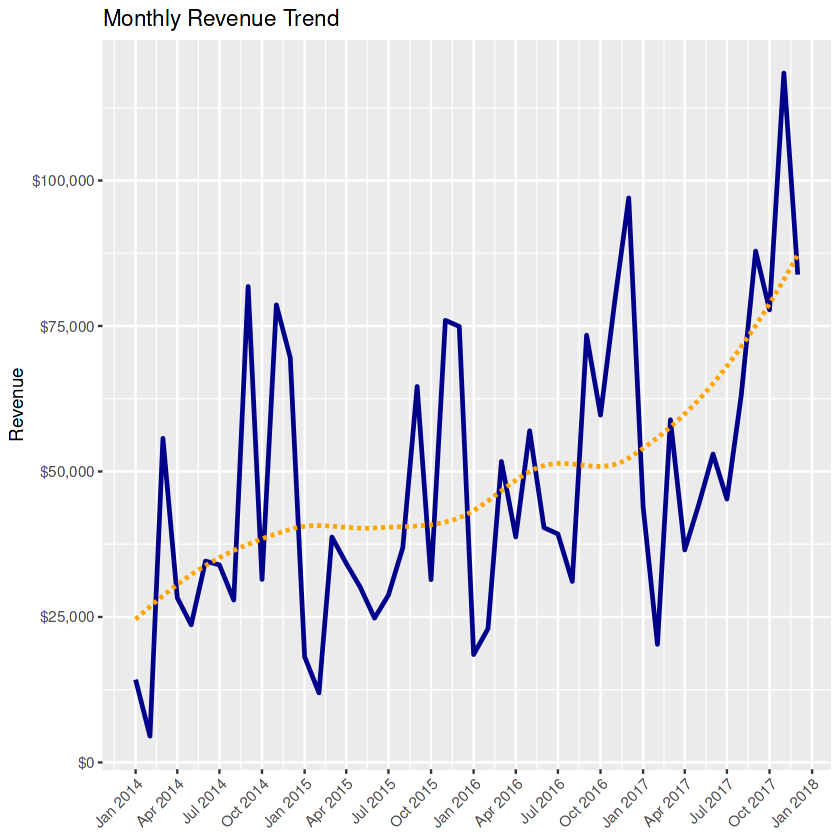

In [26]:
monthly_sales <- superStore %>%
  mutate(Month = format(Order.Date, "%Y-%m")) %>%
  group_by(Month) %>%
  summarise(Revenue = sum(Sales), Profit = sum(Profit))

ggplot(monthly_sales, aes(x = as.Date(paste0(Month, "-01")), y = Revenue)) +
  geom_line(color = "darkblue", linewidth = 1) +
  geom_smooth(method = "loess", se = FALSE, color = "orange", linetype = "dashed") +
  labs(title = "Monthly Revenue Trend", x = NULL, y = "Revenue") +
  scale_y_continuous(labels = scales::dollar) +
  scale_x_date(date_labels = "%b %Y", date_breaks = "3 months") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

**2. Monthly Revenue Trend**

The dashed trend line answers the growth question directly: revenue has grown steadily since 2014, roughly doubling from ~$25K/month baseline to ~$85K/month by late 2017 — genuine underlying growth, not just noise.

Two patterns worth acting on:

Volatility is high and increasing — the swings between good and bad months (e.g., the Jan 2016 trough vs. the spikes around it) are getting wider, not narrower, even as the trend rises. That's often a sign of a few large, lumpy deals rather than steady repeat business — worth checking against the "one dominant product" finding above.
Recurring year-end spikes (visible around Nov/Dec in multiple years) suggest real seasonality, likely holiday/fiscal-year-end purchasing. That's predictable and plannable — inventory and staffing should scale for it rather than being caught off guard.


## **3. Which categories or regions are most profitable?**

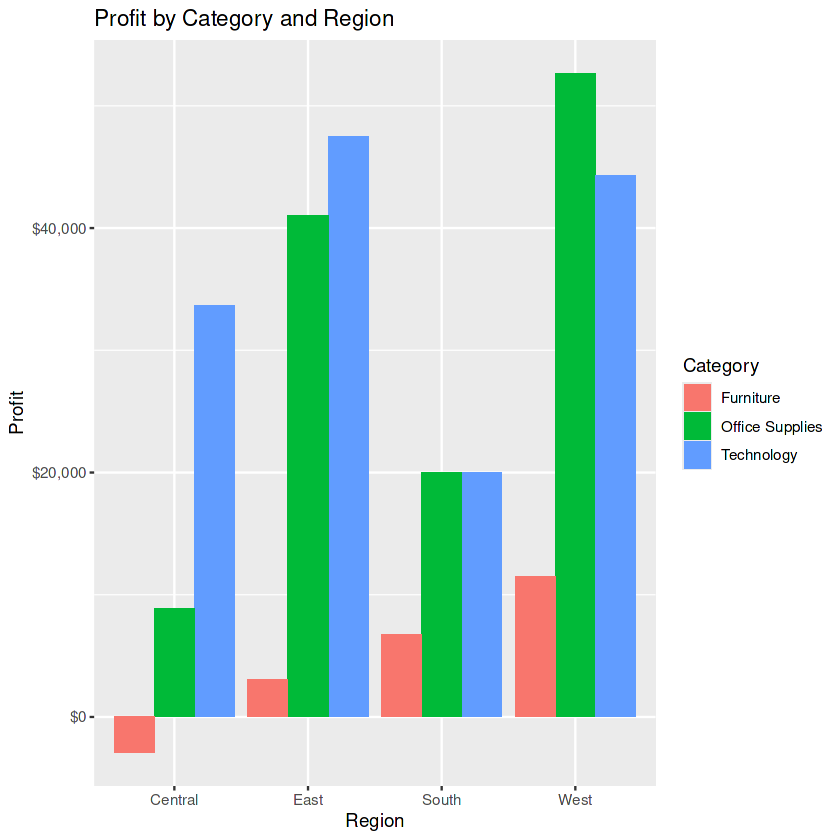

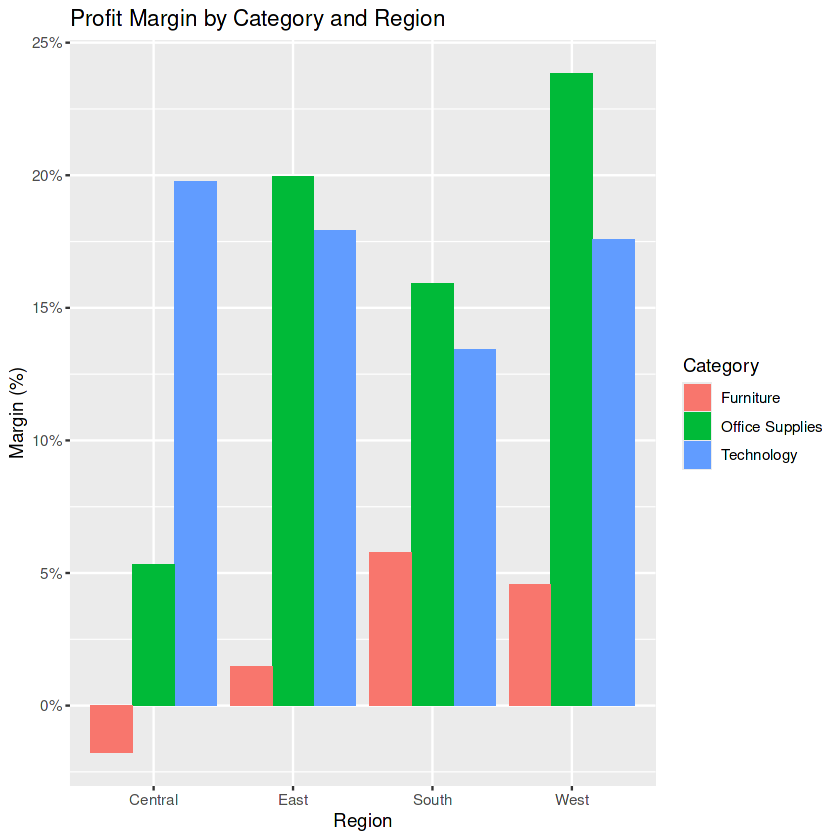

In [33]:
cat_region <- superStore %>%
  group_by(Category, Region) %>%
  summarise(Revenue = sum(Sales), Profit = sum(Profit), Margin = Profit / Revenue, .groups = "drop") %>%
  arrange(desc(Profit))

ggplot(cat_region, aes(x = Region, y = Profit, fill = Category)) +
  geom_col(position = "dodge") +
  labs(title = "Profit by Category and Region", y = "Profit") +
  scale_y_continuous(labels = scales::dollar)

# Margin is often more revealing than raw profit
ggplot(cat_region, aes(x = Region, y = Margin, fill = Category)) +
  geom_col(position = "dodge") +
  labs(title = "Profit Margin by Category and Region", y = "Margin (%)") +
  scale_y_continuous(labels = scales::percent)


**3. Profit by Category and Region**

This is the clearest actionable finding in the whole set: Furniture is barely profitable anywhere, and actively loses money in the Central region. Look at the margin chart — Furniture's margin is negative in Central and stays under 6% everywhere else, while Technology and Office Supplies both clear double digits in most regions.

Region-wise, West is your best-performing region across all three categories, and Central is consistently the weakest — it's the only region where a category (Furniture) shows negative profit at all, and its Technology margin (~20%) is meaningfully below West's (~20%+) or East's.

Business implication: if you're deciding where to focus growth investment (question 4), West + Technology/Office Supplies is your strongest combination. Central + Furniture is actively worth investigating — either fix the cost/discount structure there or scale it back.


## **4. Where should the business focus to grow faster?**

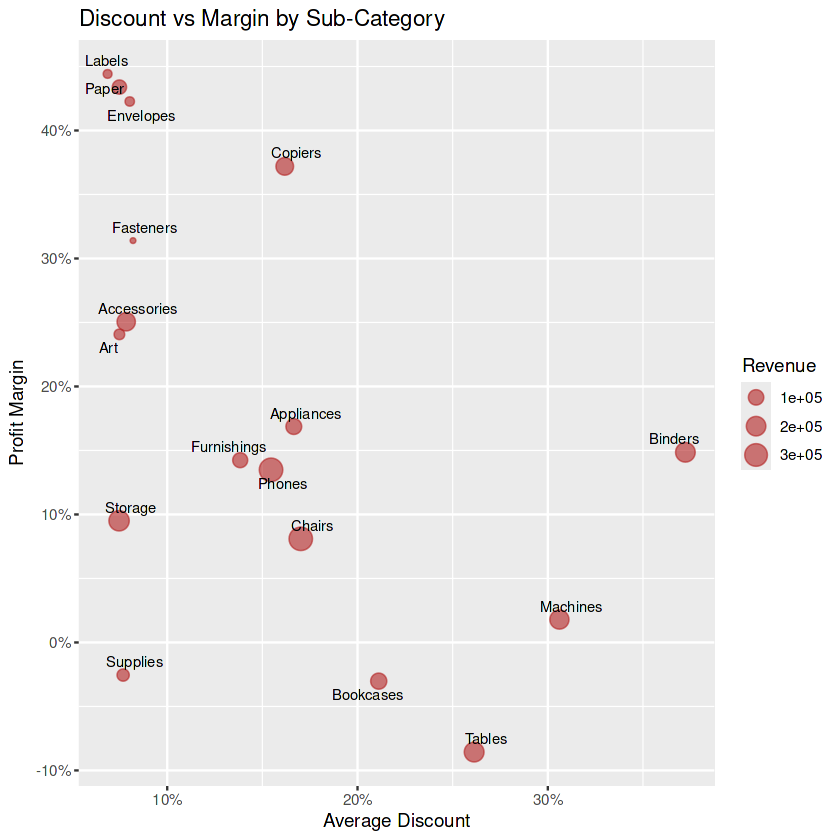

In [29]:
discount_impact <- superStore %>%
  group_by(Sub.Category) %>%
  summarise(
    Revenue = sum(Sales),
    Profit = sum(Profit),
    Margin = Profit / Revenue,
    Avg.Discount = mean(Discount)
  ) %>%
  arrange(Margin)

ggplot(discount_impact, aes(x = Avg.Discount, y = Margin, size = Revenue, label = Sub.Category)) +
  geom_point(alpha = 0.6, color = "firebrick") +
  ggrepel::geom_text_repel(size = 3) +
  labs(title = "Discount vs Margin by Sub-Category", x = "Average Discount", y = "Profit Margin") +
  scale_x_continuous(labels = scales::percent) +
  scale_y_continuous(labels = scales::percent)

**4. Discount vs. Margin by Sub-Category**

This chart explains why Furniture is unprofitable — it's not the product category itself, it's the discounting. Look at Tables and Bookcases: they sit at 20–30% average discount and both have negative margin. Compare that to Copiers, which also carries a mid-teens discount but still returns ~37% margin — so heavy discounting alone doesn't doom a product; it's the combination of high discount + already-thin base margin that kills Tables and Bookcases specifically.

At the other end, Labels, Paper, and Envelopes post 40%+ margins on minimal discounting — these are your quiet cash cows, low revenue individually but essentially free money per sale.

Concrete recommendation: cap or restrict discounting on Tables and Bookcases (or renegotiate supplier cost on them), since current discount levels are structurally erasing profit rather than just trimming it. Meanwhile, Binders show high revenue (large bubble) at a high discount (~35%) but still hold a positive ~15% margin — that's a segment that could likely take a smaller discount without losing much volume, directly recovering margin.